# Comprensión y análisis exploratorio de datos

## Objetivo
En este notebook se realiza el análisis exploratorio inicial del dataset de riesgo crediticio, con el objetivo de comprender la estructura de los datos, detectar valores faltantes, identificar posibles inconsistencias y analizar las variables disponibles antes del modelado.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ruta_base = "../data/Base_de_datos.xlsx"

df = pd.read_excel(ruta_base)

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## Interpretación inicial del dataset

A partir de la exploración inicial se identificó que el dataset contiene 10.763 registros y 23 variables.

Se observan diferentes tipos de datos:
- Variables numéricas enteras (`int64`)
- Variables numéricas decimales (`float64`)
- Variables categóricas (`object`)
- Variables de fecha (`datetime`)

También se identificó presencia de valores nulos en algunas variables relevantes, especialmente:
- `puntaje_datacredito`
- `saldo_mora`
- `saldo_total`
- `saldo_principal`
- `saldo_mora_codeudor`
- `promedio_ingresos_datacredito`
- `tendencia_ingresos`

Estas variables deberán analizarse posteriormente para determinar la mejor estrategia de tratamiento de valores faltantes.

Finalmente, se identifica la variable `Pago_atiempo` como posible variable objetivo del modelo predictivo, ya que por su nombre y contexto de negocio podría representar el comportamiento de pago de los clientes. Esta hipótesis deberá validarse durante las siguientes etapas del análisis exploratorio.

## Análisis de valores nulos

En esta sección se identifican las variables que contienen valores faltantes dentro del dataset, con el objetivo de evaluar posteriormente estrategias de tratamiento e imputación.

In [4]:
nulos = df.isnull().sum()

nulos = nulos[nulos > 0].sort_values(ascending=False)

nulos

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
dtype: int64

## Interpretación de valores nulos

Se identificaron valores faltantes en 7 variables del dataset.

Las variables con mayor cantidad de datos faltantes son:
- `tendencia_ingresos`
- `promedio_ingresos_datacredito`

Ambas presentan aproximadamente 2.900 registros nulos, lo que representa una proporción importante del dataset y requerirá un análisis específico para definir si conviene imputar, transformar o excluir estas variables.

También se observan valores faltantes en variables relacionadas con saldos y mora:
- `saldo_mora_codeudor`
- `saldo_principal`
- `saldo_mora`
- `saldo_total`

Por último, `puntaje_datacredito` presenta únicamente 6 valores nulos, por lo que su tratamiento será más sencillo.

El análisis de valores faltantes resulta fundamental para asegurar la calidad de los datos antes del entrenamiento de modelos predictivos.

## Clasificación de variables

Se realiza una clasificación inicial de las variables según su tipo de dato y naturaleza analítica.

In [5]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

variables_fecha = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

print("\nVariables de fecha:")
print(variables_fecha)

Variables numéricas:
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']

Variables categóricas:
['tipo_laboral', 'tendencia_ingresos']

Variables de fecha:
['fecha_prestamo']


## Interpretación de clasificación de variables

El dataset contiene principalmente variables numéricas relacionadas con información financiera, crediticia y demográfica de los clientes.

También se identificaron variables categóricas como:
- `tipo_laboral`
- `tendencia_ingresos`

y una variable temporal:
- `fecha_prestamo`

Es importante destacar que algunas variables almacenadas como numéricas podrían representar categorías codificadas, por ejemplo:
- `tipo_credito`
- `Pago_atiempo`

Por lo tanto, será necesario analizar su significado de negocio antes de definir el tratamiento definitivo dentro del modelado.

La correcta clasificación de variables permitirá aplicar transformaciones apropiadas en futuras etapas de feature engineering y entrenamiento de modelos.

## Estadística descriptiva inicial

Se calculan métricas estadísticas básicas para comprender la distribución general de las variables numéricas del dataset.

In [6]:
df.describe()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,...,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121664,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,...,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,...,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,...,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,...,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,...,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,...,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


## Interpretación de estadísticas descriptivas

A partir de las métricas descriptivas se observan varios aspectos relevantes del dataset:

- El capital prestado presenta una alta dispersión, con préstamos que van desde aproximadamente $360.000 hasta más de $41 millones.
- La edad de los clientes oscila entre 19 y 123 años, por lo que podrían existir valores atípicos o inconsistencias en algunos registros.
- La variable `salario_cliente` presenta valores extremadamente elevados en ciertos casos, alcanzando cifras superiores a los 22 mil millones, lo cual podría indicar presencia de outliers.
- Varias variables financieras muestran distribuciones posiblemente asimétricas, especialmente aquellas relacionadas con saldos y préstamos.
- La variable `Pago_atiempo` presenta una media cercana a 0.95, lo que sugiere un posible desbalance de clases, ya que la mayoría de los clientes aparentemente cumplen con sus pagos.

Estos hallazgos serán importantes para las siguientes etapas del análisis exploratorio y preparación de datos, especialmente en la detección de outliers, balanceo de clases y transformación de variables.

## Análisis univariable de variables numéricas

En esta sección se analizan visualmente algunas variables numéricas relevantes para comprender su distribución, dispersión y posible presencia de valores atípicos.

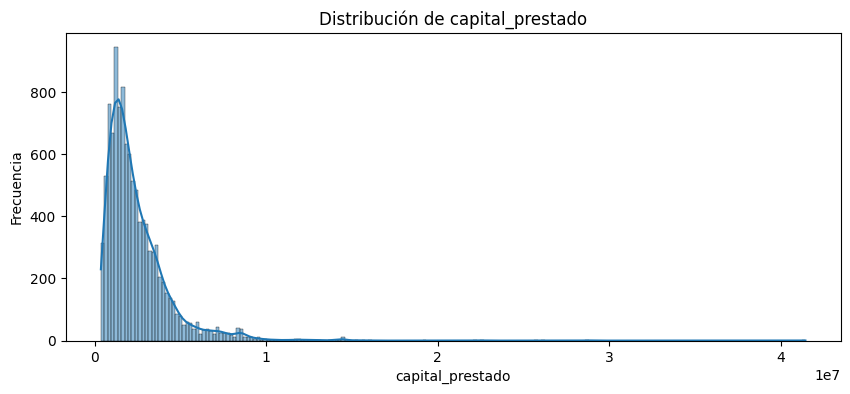

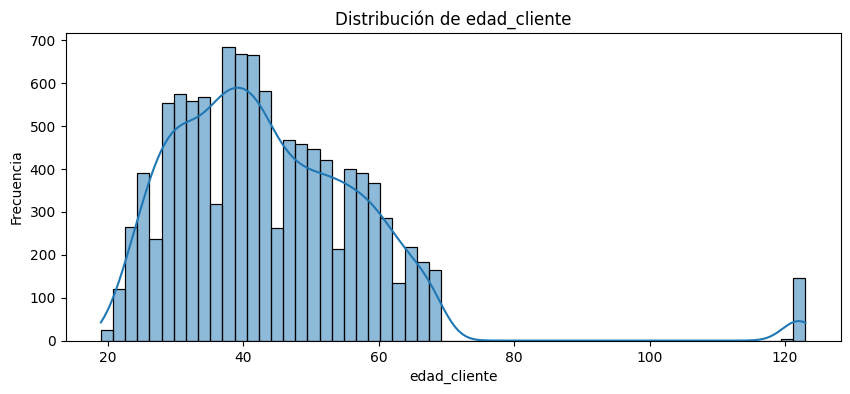

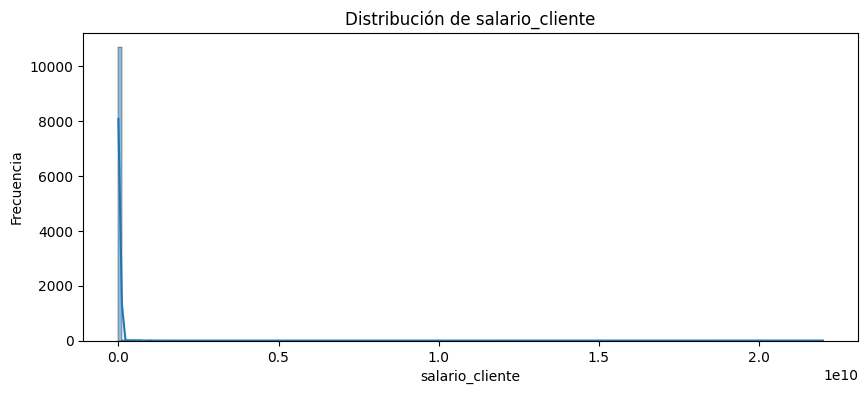

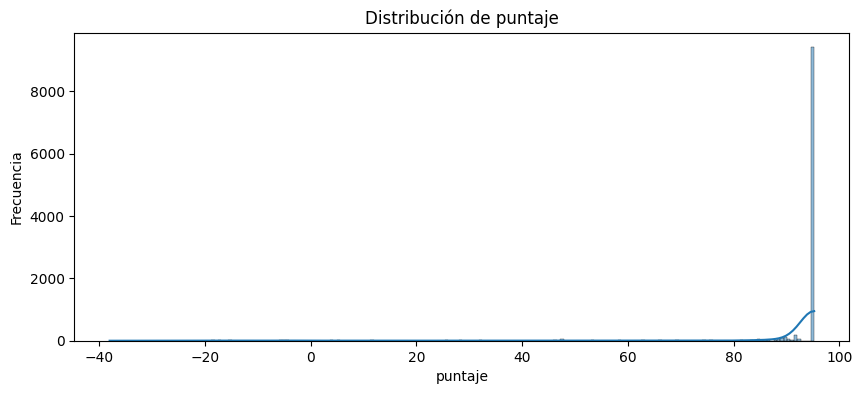

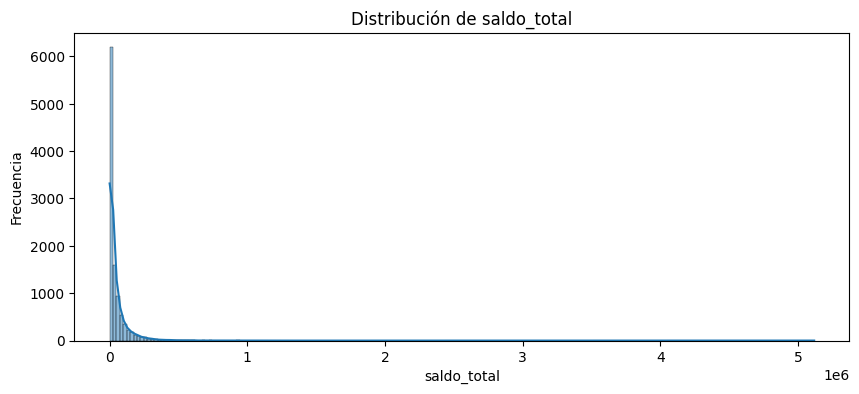

In [8]:
variables_analisis = [
    'capital_prestado',
    'edad_cliente',
    'salario_cliente',
    'puntaje',
    'saldo_total'
]

for variable in variables_analisis:
    
    plt.figure(figsize=(10,4))
    
    sns.histplot(df[variable], kde=True)
    
    plt.title(f'Distribución de {variable}')
    
    plt.xlabel(variable)
    
    plt.ylabel('Frecuencia')
    
    plt.show()

## Interpretación de distribuciones numéricas

A partir de los histogramas se observan distintos comportamientos en las variables analizadas:

- `capital_prestado` presenta una distribución fuertemente asimétrica hacia la derecha, indicando que la mayoría de los préstamos son de montos relativamente bajos, aunque existen algunos préstamos de valores muy elevados.

- `edad_cliente` muestra una distribución más cercana a una normal, concentrándose principalmente entre los 30 y 60 años. Sin embargo, se observan posibles valores atípicos cercanos a los 120 años, los cuales podrían representar inconsistencias o errores de carga.

- `salario_cliente` presenta una asimetría extrema y valores extraordinariamente altos, lo que evidencia la presencia de outliers importantes que deberán analizarse posteriormente.

- La variable `puntaje` se concentra fuertemente alrededor de valores altos, especialmente cercanos a 95, aunque también se observan valores negativos y dispersión en algunos casos particulares.

- `saldo_total` también parece presentar una distribución asimétrica, con presencia de valores extremos.

En general, varias variables financieras presentan distribuciones no normales y posibles outliers, por lo que podrían requerirse transformaciones o tratamientos específicos antes del entrenamiento de modelos.

## Detección visual de valores atípicos

Se utilizan gráficos de caja (boxplots) para identificar posibles valores atípicos en las variables numéricas relevantes.

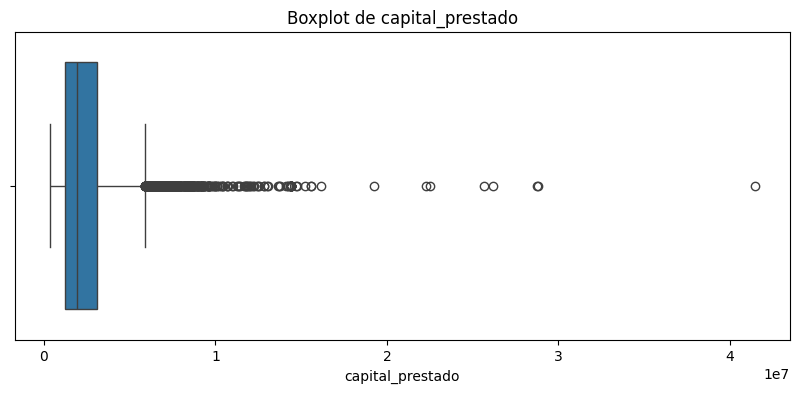

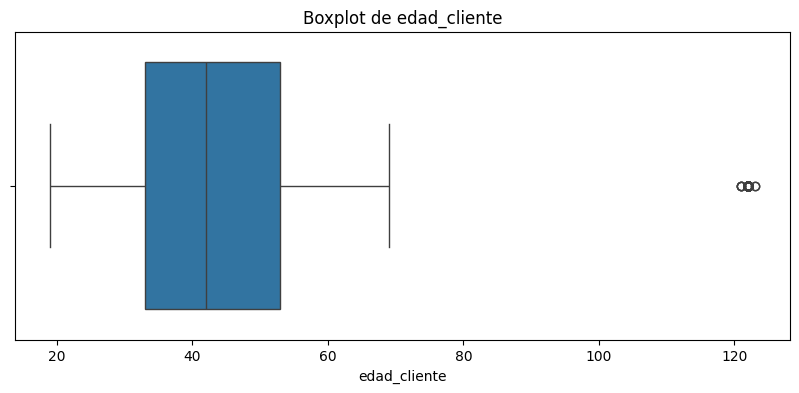

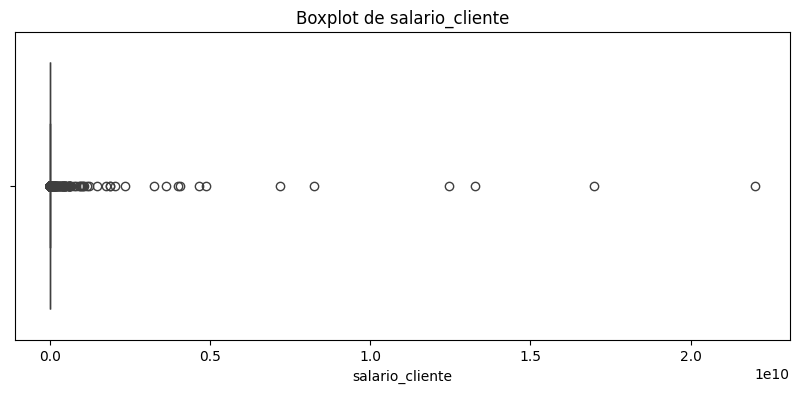

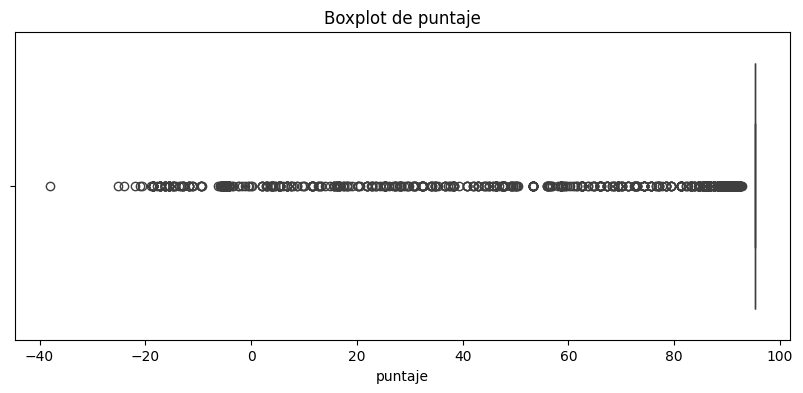

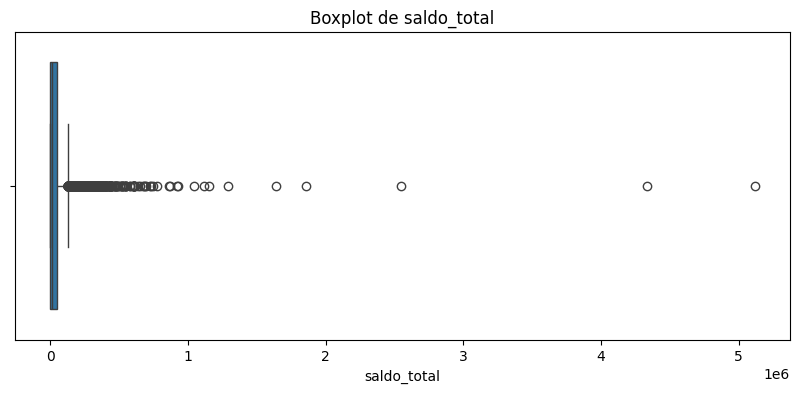

In [10]:
for variable in variables_analisis:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(x=df[variable])
    
    plt.title(f'Boxplot de {variable}')
    
    plt.xlabel(variable)
    
    plt.show()

## Interpretación de boxplots y valores atípicos

Los gráficos de caja permitieron identificar una importante presencia de valores atípicos en varias variables del dataset.

Principales hallazgos:

- `capital_prestado` presenta numerosos valores extremos superiores al comportamiento central de la distribución, lo que confirma la fuerte asimetría observada previamente en los histogramas.

- `edad_cliente` muestra algunos registros cercanos a los 120 años, los cuales podrían representar errores de carga o inconsistencias en los datos.

- `salario_cliente` contiene una gran cantidad de outliers y casos extremadamente elevados, alcanzando valores muy superiores al comportamiento promedio de la variable.

- `puntaje` presenta concentración en valores altos, aunque también se observan registros atípicos e incluso valores negativos.

- `saldo_total` evidencia una distribución altamente concentrada en valores bajos, junto con múltiples observaciones extremas alejadas del rango intercuartílico.

La presencia de outliers resulta especialmente relevante en modelos predictivos, ya que pueden afectar el rendimiento de algunos algoritmos y requerir tratamientos específicos en etapas posteriores del proyecto.

## Análisis de la variable objetivo

Se analiza la distribución de la variable objetivo `Pago_atiempo` para comprender el comportamiento general de las clases dentro del dataset.

In [11]:
df['Pago_atiempo'].value_counts()

Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

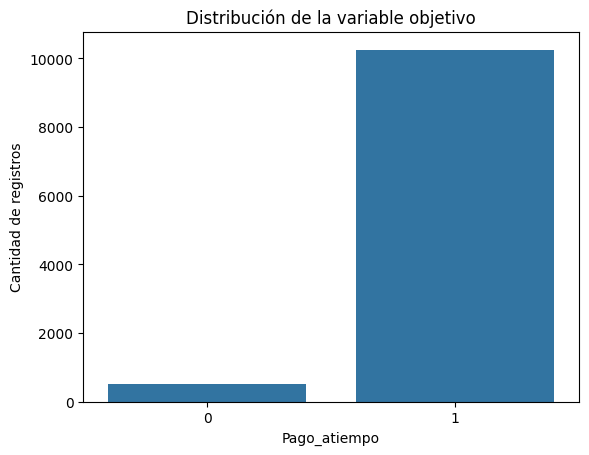

In [12]:
sns.countplot(x=df['Pago_atiempo'])

plt.title('Distribución de la variable objetivo')

plt.xlabel('Pago_atiempo')

plt.ylabel('Cantidad de registros')

plt.show()

## Interpretación de la variable objetivo

La variable objetivo `Pago_atiempo` presenta un fuerte desbalance de clases.

Se observa que:
- La clase `1` representa la gran mayoría de los registros (10.252 casos).
- La clase `0` aparece únicamente en 511 registros.

Esto indica que la mayoría de los clientes del dataset cumplen con sus pagos, mientras que los casos de incumplimiento representan una proporción considerablemente menor.

El desbalance de clases es un aspecto crítico en problemas de clasificación, ya que puede generar modelos sesgados hacia la clase mayoritaria.

Por este motivo, en etapas posteriores podrían evaluarse técnicas de tratamiento como:
- ajuste de métricas,
- balanceo de clases,
- modificación de umbrales de decisión,
- o técnicas de sobremuestreo.

## Análisis de correlación entre variables numéricas

Se analiza la correlación entre las variables numéricas del dataset para identificar relaciones lineales relevantes y posibles asociaciones entre variables financieras y de comportamiento crediticio.

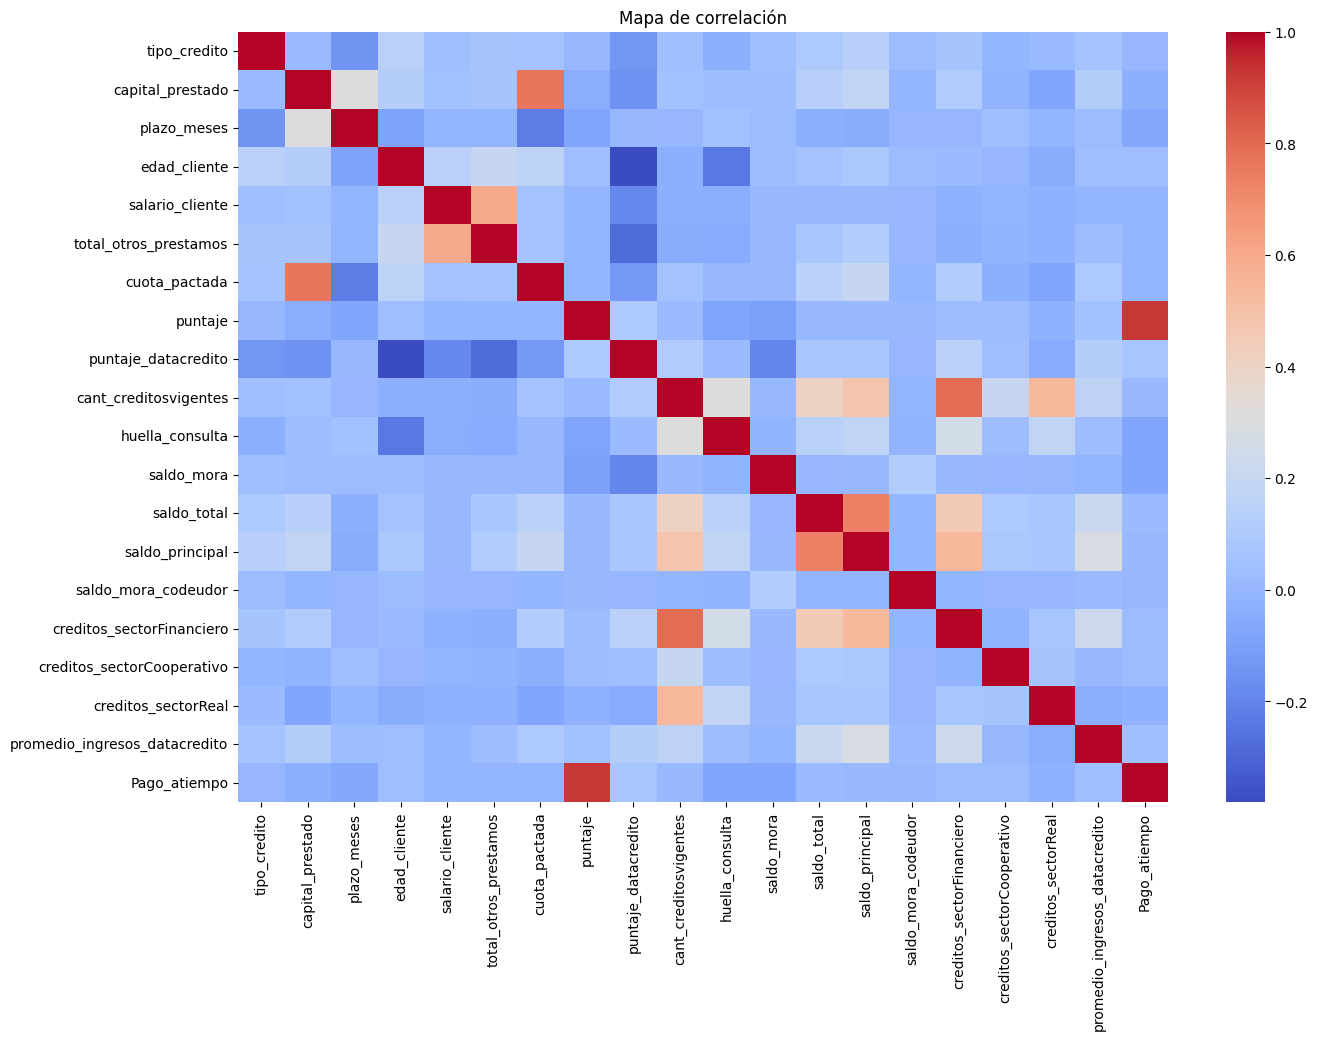

In [13]:
correlacion = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    correlacion,
    cmap='coolwarm',
    annot=False
)

plt.title('Mapa de correlación')

plt.show()

## Interpretación del mapa de correlación

El análisis de correlación permitió identificar algunas relaciones relevantes entre variables numéricas del dataset.

Principales hallazgos:

- `capital_prestado` presenta una correlación positiva con `cuota_pactada`, lo cual resulta consistente desde el punto de vista financiero, ya que préstamos mayores suelen generar cuotas más elevadas.

- `salario_cliente` muestra relación positiva con `total_otros_prestamos`, indicando que clientes con mayores ingresos podrían acceder a más productos crediticios.

- Se observa una correlación positiva entre:
  - `saldo_total`
  - `saldo_principal`
  - `creditos_sectorFinanciero`
  
  lo cual sugiere asociaciones entre endeudamiento y cantidad de créditos vigentes.

- La variable `puntaje` presenta una correlación positiva importante con `Pago_atiempo`, indicando que clientes con mejor puntaje tienden a cumplir con sus pagos.

- En general, la mayoría de las correlaciones son moderadas o bajas, lo cual puede ser favorable para modelos predictivos al reducir problemas severos de multicolinealidad.

El análisis de correlaciones permite comprender mejor las relaciones financieras presentes en el dataset y aporta información valiosa para futuras etapas de modelado.

## Análisis de variables categóricas

En esta sección se analizan las variables categóricas del dataset para comprender la distribución de categorías y detectar posibles desbalances o patrones relevantes.

In [14]:
variables_categoricas

['tipo_laboral', 'tendencia_ingresos']

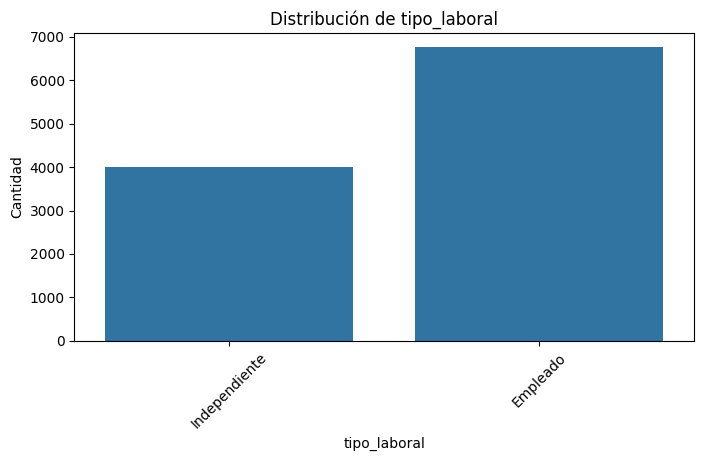

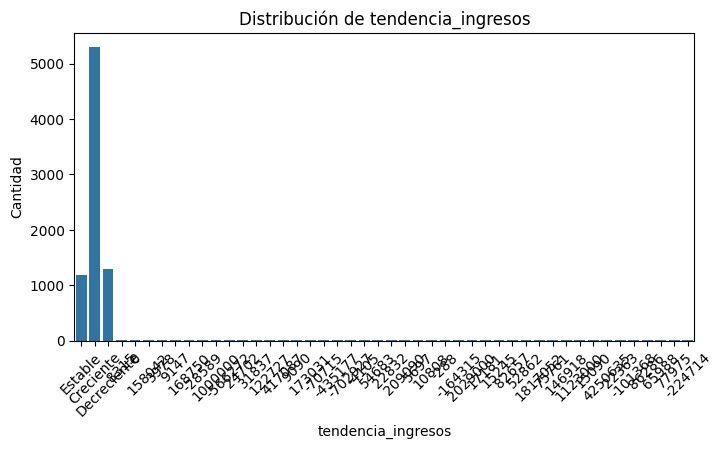

In [15]:
for variable in variables_categoricas:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(x=df[variable])
    
    plt.title(f'Distribución de {variable}')
    
    plt.xlabel(variable)
    
    plt.ylabel('Cantidad')
    
    plt.xticks(rotation=45)
    
    plt.show()

In [16]:
df['tendencia_ingresos'].value_counts(dropna=False).head(20)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
168750            1
3978              1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
Name: count, dtype: int64

In [17]:
df['tendencia_ingresos'].unique()

array(['Estable', 'Creciente', nan, 'Decreciente', 8315, 0, 158042, 3978,
       9147, 168750, -28589, 1000000, -566272, 24702, 31837, 122727,
       417087, 9090, 173031, -70715, -435177, -702927, -4105, 54683,
       22832, 209090, 5697, 10808, -288, -164315, 2029000, 17181, 15245,
       82657, 52862, 1817052, 75761, 146918, 1123000, 15090, 4250635,
       22363, -101368, 86286, 65988, 77975, -224714], dtype=object)

## Interpretación de variables categóricas

La variable `tipo_laboral` presenta principalmente dos categorías:
- `Empleado`
- `Independiente`

Se observa una mayor proporción de clientes empleados dentro del dataset.

Por otro lado, durante el análisis de `tendencia_ingresos` se detectaron inconsistencias importantes en la calidad de los datos.

Si bien la variable contiene categorías esperadas como:
- `Creciente`
- `Estable`
- `Decreciente`

también aparecen numerosos valores numéricos positivos y negativos, incluyendo cifras extremadamente elevadas.

Esto sugiere posibles problemas de carga, errores en el origen de los datos o mezcla de tipos de información dentro de la misma columna.

Debido a estas inconsistencias, esta variable requerirá un tratamiento especial en etapas posteriores de limpieza y preprocesamiento.

## Análisis bivariable entre variables numéricas y la variable objetivo

En esta sección se analiza la relación entre algunas variables numéricas relevantes y la variable objetivo `Pago_atiempo`, con el objetivo de identificar posibles patrones asociados al comportamiento de pago de los clientes.

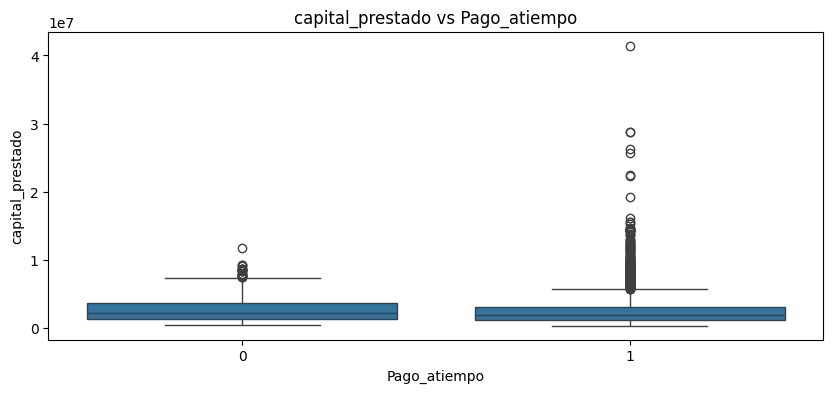

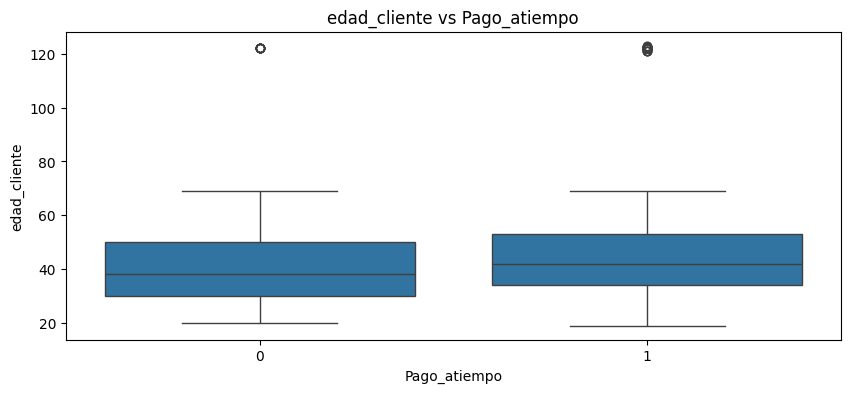

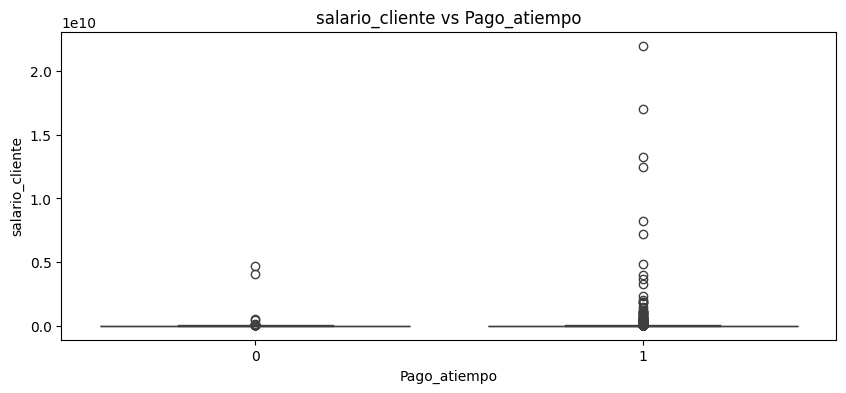

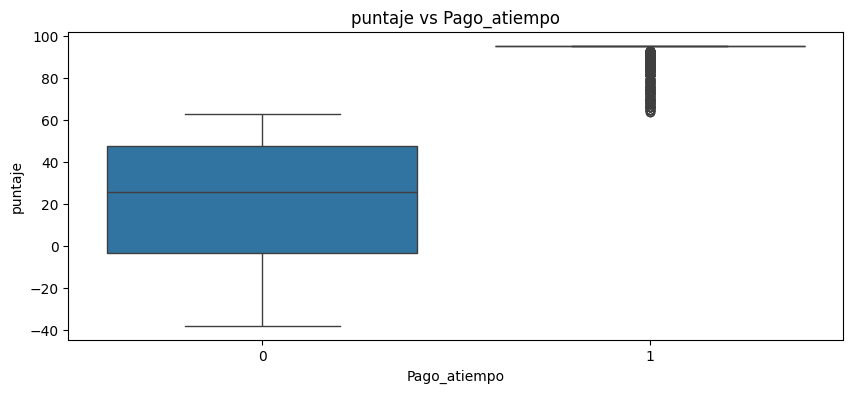

In [18]:
variables_bivariadas = [
    'capital_prestado',
    'edad_cliente',
    'salario_cliente',
    'puntaje'
]

for variable in variables_bivariadas:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(
        x='Pago_atiempo',
        y=variable,
        data=df
    )
    
    plt.title(f'{variable} vs Pago_atiempo')
    
    plt.show()

## Interpretación del análisis bivariable numérico

El análisis bivariable permitió identificar diferencias relevantes entre las variables numéricas y el comportamiento de pago de los clientes.

Principales observaciones:

- `puntaje` presenta una diferencia muy marcada entre ambas clases de `Pago_atiempo`. Los clientes que cumplen con sus pagos muestran puntajes considerablemente más altos, lo que sugiere que esta variable podría tener una fuerte capacidad predictiva dentro del modelo.

- `capital_prestado` muestra distribuciones relativamente similares entre ambas clases, aunque se observan mayores valores extremos en clientes que realizaron pagos a tiempo.

- `edad_cliente` no evidencia diferencias extremadamente marcadas entre clases, aunque los clientes con pagos al día parecen presentar una mediana ligeramente superior.

- `salario_cliente` presenta una gran dispersión y numerosos valores atípicos en ambas clases, dificultando una separación visual clara entre clientes cumplidores e incumplidores.

En general, el análisis sugiere que algunas variables, especialmente `puntaje`, podrían aportar información relevante para la predicción del comportamiento de pago.

## Relación entre variables categóricas y la variable objetivo

Se analiza la relación entre las variables categóricas y la variable objetivo `Pago_atiempo` para identificar posibles patrones de comportamiento entre categorías.

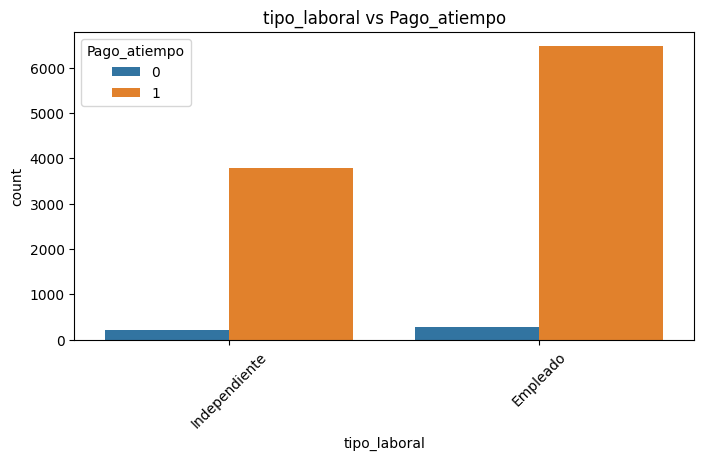

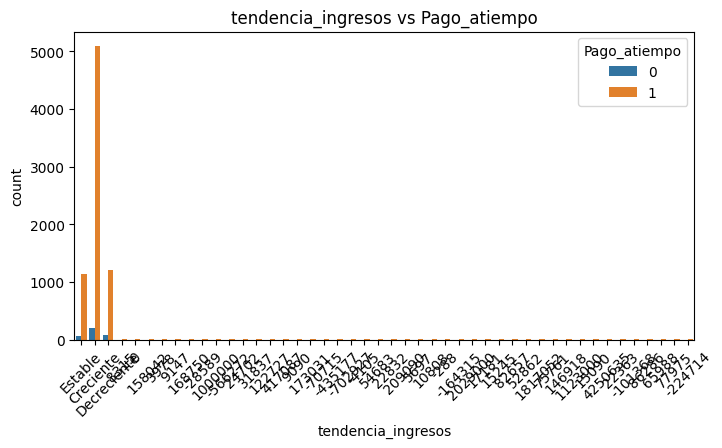

In [19]:
for variable in variables_categoricas:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        x=variable,
        hue='Pago_atiempo',
        data=df
    )
    
    plt.title(f'{variable} vs Pago_atiempo')
    
    plt.xticks(rotation=45)
    
    plt.show()

## Interpretación del análisis bivariable categórico

El análisis de variables categóricas frente a `Pago_atiempo` permitió observar algunos patrones relevantes.

Principales observaciones:

- En `tipo_laboral`, tanto empleados como independientes presentan una mayoría de clientes con pagos al día, lo cual resulta consistente con el fuerte desbalance previamente identificado en la variable objetivo.

- La categoría `Empleado` presenta una mayor cantidad total de registros dentro del dataset.

- En el caso de `tendencia_ingresos`, los gráficos vuelven a evidenciar inconsistencias en los datos, ya que aparecen numerosos valores numéricos mezclados con categorías textuales esperadas como:
  - `Creciente`
  - `Estable`
  - `Decreciente`

- Estas inconsistencias dificultan la interpretación directa de la variable y refuerzan la necesidad de aplicar procesos de limpieza y normalización en etapas posteriores.

En general, las variables categóricas aportan información complementaria sobre el perfil financiero y laboral de los clientes.

# Conclusiones generales del análisis exploratorio

A partir del análisis exploratorio realizado sobre el dataset de riesgo crediticio, se identificaron múltiples aspectos relevantes para las siguientes etapas del proyecto.

## Principales hallazgos

- El dataset contiene 10.763 registros y 23 variables con información financiera, crediticia y demográfica de clientes.

- Se detectaron valores faltantes en varias variables, especialmente en:
  - `tendencia_ingresos`
  - `promedio_ingresos_datacredito`
  - variables relacionadas con saldos y mora.

- Varias variables presentan distribuciones fuertemente asimétricas y una importante presencia de valores atípicos, particularmente:
  - `salario_cliente`
  - `capital_prestado`
  - `saldo_total`

- Se identificaron posibles inconsistencias en algunas variables, especialmente:
  - edades cercanas a 120 años,
  - valores negativos en `puntaje`,
  - mezcla de categorías y valores numéricos en `tendencia_ingresos`.

- La variable objetivo `Pago_atiempo` presenta un fuerte desbalance de clases, con predominio de clientes que cumplen con sus pagos.

- El análisis bivariable permitió identificar que variables como `puntaje` podrían tener una fuerte capacidad predictiva para el comportamiento de pago.

## Próximos pasos

A partir de estos hallazgos, las siguientes etapas del proyecto estarán enfocadas en:

- limpieza y tratamiento de datos,
- imputación de valores faltantes,
- tratamiento de outliers,
- transformación de variables,
- feature engineering,
- entrenamiento y evaluación de modelos predictivos.